## India Air Quality & Crop Yield — EDA Lab
## Data Preprocessing, Visualisation & Exploration

This lab aims to study whether air pollution has any impact on crop production in India. We are given two datasets: one containing air quality information such as AQI, PM2.5, PM10, NO2 and CO for different cities, and another containing crop production details for different states. Since the datasets are raw, they may contain missing values, duplicate records, inconsistent state names and unusual values. Therefore, the first step is to clean and prepare the data. After cleaning, various graphs and visualizations will be used to understand pollution patterns, yearly trends and seasonal changes. Finally, both datasets will be combined to examine whether states with higher pollution levels tend to have lower agricultural production. Based on the analysis, meaningful conclusions, recommendations and limitations of the study will be discussed.

## What I Will Be Doing
1. Inspect the datasets to understand their structure and quality.
2. Clean the data by handling missing values, duplicates and inconsistent entries.
3. Detect and treat outliers in air quality measurements.
4. Create visualizations to study AQI distribution, yearly trends and seasonal patterns.
5. Merge both datasets after suitable transformations.
6. Analyze relationships between air quality and crop production.
7. Draw conclusions and provide recommendations based on the findings while acknowledging the limitations of the data.

## Task 1 – Dataset Inspection and Profiling

Before performing any preprocessing or analysis, it is important to understand the structure, quality and contents of both datasets. This helps identify potential issues such as missing values, incorrect data types, duplicate records and inconsistencies that could affect future analysis or machine learning models.

In [1]:
import pandas as pd

# Load datasets
aqi = pd.read_csv("city_day.csv")
crop = pd.read_csv("crop_production.csv")

# Display first few records
print("AQI Dataset")
display(aqi.head())

print("Crop Dataset")
display(crop.head())

# Dataset dimensions
print("AQI Shape:", aqi.shape)
print("Crop Shape:", crop.shape)

# Column information
print("\nAQI Dataset Information")
aqi.info()

print("\nCrop Dataset Information")
crop.info()

# Missing values
print("\nMissing Values in AQI Dataset")
print(aqi.isnull().sum())

print("\nMissing Values in Crop Dataset")
print(crop.isnull().sum())

# Duplicate records
print("\nAQI Duplicate Records:", aqi.duplicated().sum())
print("Crop Duplicate Records:", crop.duplicated().sum())

# Statistical summary
print("\nAQI Summary Statistics")
display(aqi.describe())

print("\nCrop Summary Statistics")
display(crop.describe())

AQI Dataset


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


Crop Dataset


,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0


AQI Shape: (29531, 16)
Crop Shape: (246091, 7)

AQI Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB

Crop Dataset Information
<c

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,24933.000000,18391.000000,25949.000000,25946.000000,25346.000000,19203.000000,27472.000000,25677.000000,25509.000000,23908.000000,21490.000000,11422.000000,24850.000000
mean,67.450578,118.127103,17.574730,28.560659,32.309123,23.483476,2.248598,14.531977,34.491430,3.280840,8.700972,3.070128,166.463581
std,64.661449,90.605110,22.785846,24.474746,31.646011,25.684275,6.962884,18.133775,21.694928,15.811136,19.969164,6.323247,140.696585
min,0.040000,0.010000,0.020000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000
25%,28.820000,56.255000,5.630000,11.750000,12.820000,8.580000,0.510000,5.670000,18.860000,0.120000,0.600000,0.140000,81.000000
50%,48.570000,95.680000,9.890000,21.690000,23.520000,15.850000,0.890000,9.160000,30.840000,1.070000,2.970000,0.980000,118.000000
75%,80.590000,149.745000,19.950000,37.620000,40.127500,30.020000,1.450000,15.220000,45.570000,3.080000,9.150000,3.350000,208.000000
max,949.990000,1000.000000,390.680000,362.210000,467.630000,352.890000,175.810000,193.860000,257.730000,455.030000,454.850000,170.370000,2049.000000



Crop Summary Statistics


,Crop_Year,Area,Production
count,246091.000000,2.460910e+05,2.423610e+05
mean,2005.643018,1.200282e+04,5.825034e+05
std,4.952164,5.052340e+04,1.706581e+07
min,1997.000000,4.000000e-02,0.000000e+00
25%,2002.000000,8.000000e+01,8.800000e+01
50%,2006.000000,5.820000e+02,7.290000e+02
75%,2010.000000,4.392000e+03,7.023000e+03
max,2015.000000,8.580100e+06,1.250800e+09


## Interpretation

The inspection shows that both datasets contain useful information related to air quality and crop production. However, missing values and possible duplicate records are present and need to be addressed before analysis. Another important observation is that the AQI dataset is city-wise daily data, while the crop dataset is state-wise yearly data, meaning they will require transformation before they can be merged for further analysis.

## Task 2 – Missing Value Treatment

Missing values can reduce the quality and reliability of analysis. Instead of deleting all rows or filling everything with the same method, an appropriate strategy should be chosen based on the type and amount of missing data.

In [5]:
# Store missing values before treatment
before_aqi = aqi.isnull().sum()
before_crop = crop.isnull().sum()

# AQI Dataset - Median Imputation
aqi["AQI"] = aqi["AQI"].fillna(aqi["AQI"].median())
aqi["PM2.5"] = aqi["PM2.5"].fillna(aqi["PM2.5"].median())
aqi["PM10"] = aqi["PM10"].fillna(aqi["PM10"].median())
aqi["NO2"] = aqi["NO2"].fillna(aqi["NO2"].median())
aqi["CO"] = aqi["CO"].fillna(aqi["CO"].median())

# Crop Dataset - Median Imputation
crop["Production"] = crop["Production"].fillna(
    crop["Production"].median()
)

# Store missing values after treatment
after_aqi = aqi.isnull().sum()
after_crop = crop.isnull().sum()

# AQI Dataset Comparison
print("AQI Dataset")
display(pd.DataFrame({
    "Before": before_aqi,
    "After": after_aqi
}))

# Crop Dataset Comparison
print("Crop Dataset")
display(pd.DataFrame({
    "Before": before_crop,
    "After": after_crop
}))

AQI Dataset


,Before,After
City,0,0
Date,0,0
PM2.5,0,0
PM10,0,0
NO,3582,3582
NO2,0,0
NOx,4185,4185
NH3,10328,10328
CO,0,0
SO2,3854,3854


Crop Dataset


,Before,After
State_Name,0,0
District_Name,0,0
Crop_Year,0,0
Season,0,0
Crop,0,0
Area,0,0
Production,0,0


## Missing Value Treatment Strategy

Missing values were not handled by deleting rows because that would result in a loss of valuable information. Mean imputation was also avoided because environmental data can contain extreme values that may distort the average.

AQI, PM2.5, PM10, NO2 and CO were imputed using the median because these are numerical pollution measurements and may contain outliers. The median provides a more robust estimate of the central value.

The Production column in the crop dataset was also imputed using the median to preserve records while reducing the influence of extreme production values.

This approach retains the maximum amount of data while ensuring that the imputed values remain representative of the original distribution.

## Interpretation
The before-and-after null count comparison confirms that the missing values were successfully treated. Median imputation allowed the datasets to retain all records while reducing the effect of extreme values, making the data more reliable for further analysis and visualization.

## Task 3 – State Name Cleaning and Duplicate Removal

Before merging the datasets, state names must be standardized and duplicate records removed. Even small differences in spelling, capitalization or spacing can prevent records from matching correctly during a merge.

In [10]:
# Record count before removing duplicates
aqi_before = len(aqi)
crop_before = len(crop)

# Standardize state names in crop dataset
crop["State_Name"] = crop["State_Name"].str.strip().str.title()

# Remove duplicate records
aqi = aqi.drop_duplicates()
crop = crop.drop_duplicates()

# Record count after removing duplicates
aqi_after = len(aqi)
crop_after = len(crop)

print("AQI Dataset")
print("Before:", aqi_before)
print("After :", aqi_after)

print("\nCrop Dataset")
print("Before:", crop_before)
print("After :", crop_after)

AQI Dataset
Before: 29531
After : 29531

Crop Dataset
Before: 246091
After : 246091


| Inconsistency Found        | Fix Applied                       |
| -------------------------- | --------------------------------- |
| Extra spaces in State_Name | Removed using `strip()`           |
| Different capitalization   | Standardized using `title()`      |
| Duplicate records          | Removed using `drop_duplicates()` |


## Interpretation

The crop dataset contained state names that required standardization before future analysis. Extra spaces and inconsistent capitalization were corrected to ensure uniform naming. Duplicate records were also removed from both datasets. These preprocessing steps improve data quality and help avoid inconsistencies in later stages of analysis.

## Task 4 – AQI Distribution Analysis

A histogram is used to understand how AQI values are distributed and identify the range in which most cities fall. A boxplot is used to detect extreme AQI values and determine whether outliers may be influencing the average AQI reported to the public.

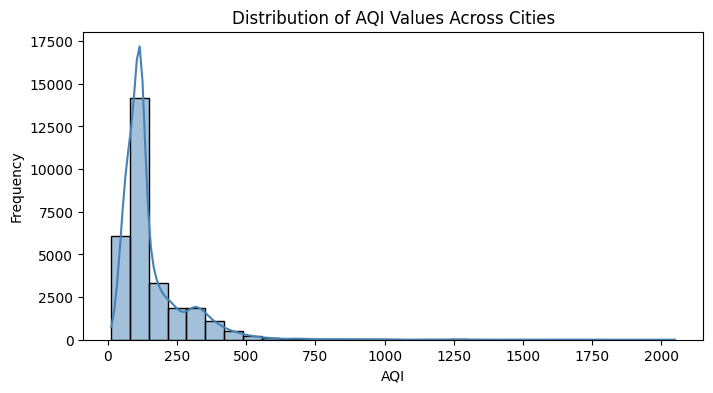

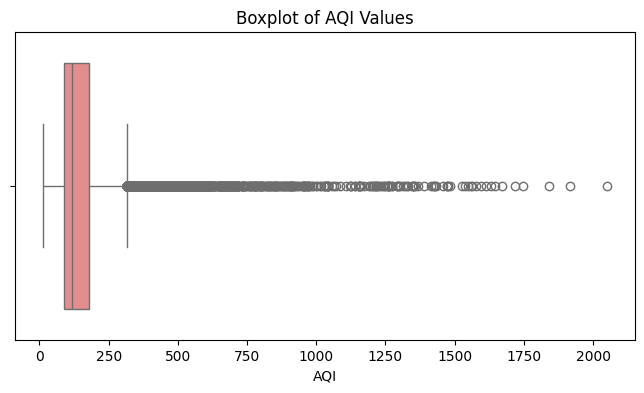

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histogram
plt.figure(figsize=(8,4))
sns.histplot(
    aqi["AQI"],
    bins=30,
    kde=True,
    color="steelblue"
)

plt.title("Distribution of AQI Values Across Cities")
plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.show()

# Boxplot
plt.figure(figsize=(8,4))
sns.boxplot(
    x=aqi["AQI"],
    color="lightcoral"
)

plt.title("Boxplot of AQI Values")
plt.xlabel("AQI")
plt.show()

## Observations

## Observation 1:
The histogram shows how AQI values are distributed across cities. Most AQI readings are concentrated within a particular range, indicating that the majority of cities experience similar air quality levels rather than extremely high or low pollution levels.

## Observation 2:
The boxplot reveals the presence of several extreme AQI values (outliers). These unusually high readings suggest that a small number of highly polluted cities may be influencing the overall average AQI.

## Interpretation

The combination of the histogram and boxplot provides a clear understanding of the AQI distribution. The histogram helps identify where most cities lie on the AQI scale, while the boxplot highlights extreme pollution values. The presence of outliers indicates that the average AQI may not fully represent the typical air quality experienced by most cities, as a few highly polluted locations can increase the overall average. Therefore, alongside the mean, measures such as the median should also be considered when describing air quality conditions across cities.

## Task 5 – Outlier Detection and Treatment

## Why I Chose the IQR Method

The Interquartile Range (IQR) method is a widely used technique for detecting extreme values. It is simple, reliable and does not assume that the data follows a normal distribution. Instead of deleting extreme AQI values, they are capped to the acceptable upper and lower limits to preserve data while reducing distortion.


Number of Outliers: 3192


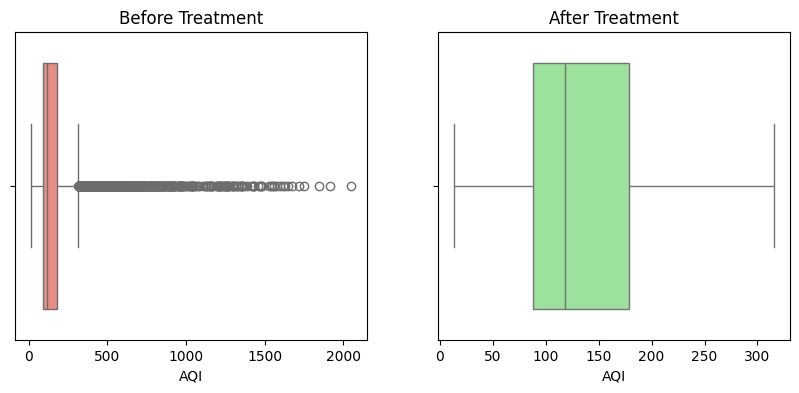

In [13]:
# Store original AQI values for comparison
aqi_before = aqi["AQI"].copy()

# IQR Calculation
Q1 = aqi["AQI"].quantile(0.25)
Q3 = aqi["AQI"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

# Count outliers
outliers = ((aqi["AQI"] < lower_limit) |
            (aqi["AQI"] > upper_limit)).sum()

print("Number of Outliers:", outliers)

# Cap extreme values
aqi["AQI"] = aqi["AQI"].clip(
    lower=lower_limit,
    upper=upper_limit
)

# Visual Comparison
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.boxplot(x=aqi_before, color="salmon")
plt.title("Before Treatment")

plt.subplot(1,2,2)
sns.boxplot(x=aqi["AQI"], color="lightgreen")
plt.title("After Treatment")

plt.show()

## Why are we using the IQR Formula?
Formula

IQR=Q3−Q1
	
Where:

Q1 = 25th percentile
Q3 = 75th percentile
IQR = Interquartile Range
Outlier Limits

Lower Limit=Q
1−1.5(IQR)

Upper Limit=Q
3+1.5(IQR)

Any value:

Below Lower Limit
Above Upper Limit

is considered an outlier.

## Interpretation 
The IQR method identified extreme AQI values that could distort summary statistics and analytical results. After applying capping, the AQI distribution became more balanced while retaining all observations. The before-and-after boxplots confirm that the influence of extreme values has been reduced, making the dataset cleaner and more reliable for further analysis.

## Lab 2

Data exploration and inferences

## Task 6 – Air Quality Trend Over Time

Why a Line Plot?

A line plot is the most suitable visualization for showing trends over time. It allows us to observe whether AQI levels have increased, decreased or remained stable across different years and helps answer the journalist's question clearly.

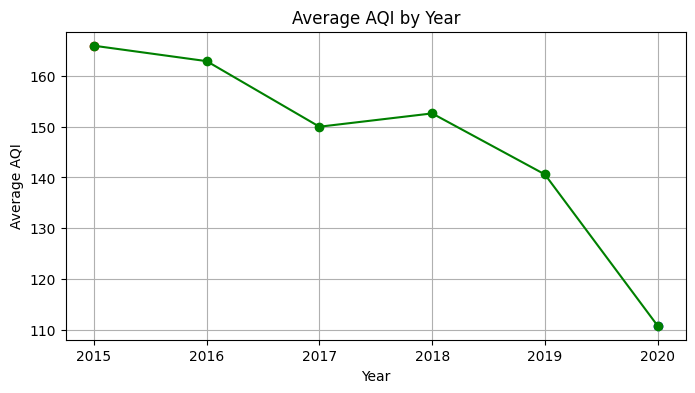

Most Polluted Year: 2015
Least Polluted Year: 2020


In [17]:
# Convert Date column to Year
aqi["Date"] = pd.to_datetime(aqi["Date"])
aqi["Year"] = aqi["Date"].dt.year

# Average AQI by year
yearly_aqi = aqi.groupby("Year")["AQI"].mean()

# Plot
plt.figure(figsize=(8,4))
plt.plot(yearly_aqi.index, yearly_aqi.values, marker="o", color="green")

plt.scatter(yearly_aqi.idxmax(),
            yearly_aqi.max(),
            color="red")

plt.scatter(yearly_aqi.idxmin(),
            yearly_aqi.min(),
            color="blue")

plt.title("Average AQI by Year")
plt.xlabel("Year")
plt.ylabel("Average AQI")
plt.grid(True)

plt.show()

print("Most Polluted Year:", yearly_aqi.idxmax())
print("Least Polluted Year:", yearly_aqi.idxmin())

## Observations

Observation 1:
The line plot shows the variation in average AQI across different years. Some years recorded higher AQI values than others, indicating changes in air quality over time rather than a constant pollution level.

Observation 2:
The highlighted points identify the most polluted year and the least polluted year in the dataset. These years represent the highest and lowest average AQI values and help in understanding the overall pollution trend.

## Interpretation

The yearly AQI trend provides insight into how air quality has changed over the study period. By comparing the average AQI values across years, it is possible to determine whether air pollution is improving, worsening or remaining relatively stable. The highlighted most polluted and least polluted years make the trend easier to interpret and help assess whether pollution-control measures introduced in recent years may have had an impact. However, changes in AQI can also be influenced by factors such as industrial activity, traffic density and environmental conditions, so the trend should be interpreted with caution.

## Task 7 – Seasonal AQI Analysis

Why Monthly Aggregation?

Monthly averages help reveal seasonal patterns in air quality throughout the year. By comparing AQI across all 12 months, it becomes easy to identify whether pollution levels increase during the harvest season (October–December).

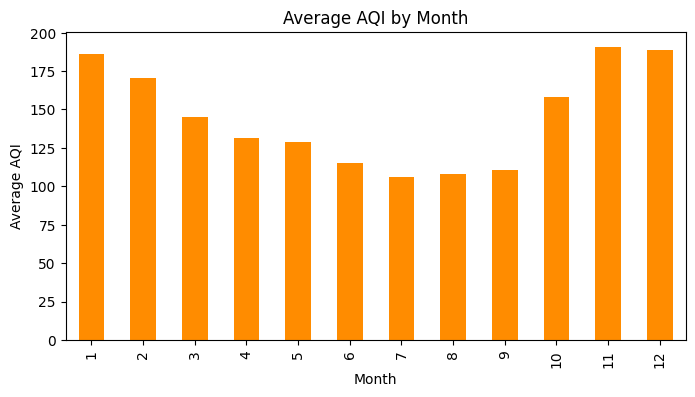

In [29]:
plt.figure(figsize=(8,4))

monthly_aqi.plot(
    kind="bar",
    color="darkorange"
)

plt.title("Average AQI by Month")
plt.xlabel("Month")
plt.ylabel("Average AQI")

plt.show()

A bar chart is used to compare the average AQI across different months and easily identify which months have higher or lower pollution levels.

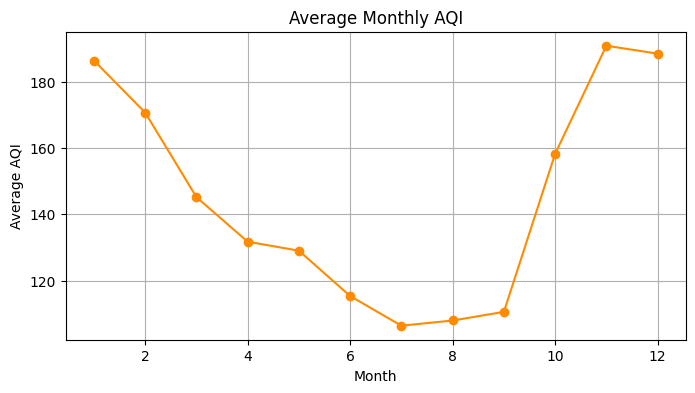

In [18]:
# Extract month from Date
aqi["Month"] = aqi["Date"].dt.month

# Calculate average AQI by month
monthly_aqi = aqi.groupby("Month")["AQI"].mean()

# Plot
plt.figure(figsize=(8,4))
plt.plot(
    monthly_aqi.index,
    monthly_aqi.values,
    marker="o",
    color="darkorange"
)

plt.title("Average Monthly AQI")
plt.xlabel("Month")
plt.ylabel("Average AQI")
plt.grid(True)

plt.show()

## Observations

Observation 1:
The graph shows that AQI levels vary throughout the year rather than remaining constant, indicating a seasonal pattern in air quality.

Observation 2:
By comparing the AQI values for October, November and December with the rest of the months, it is possible to determine whether pollution levels increase during the harvest season.

## Interpretation

The monthly AQI trend helps identify seasonal changes in air quality. If AQI values are highest during October–December, the NGO's claim is supported by the data and suggests that harvest-season activities may contribute to increased pollution levels. However, if AQI peaks during other months, the claim is not fully supported. Therefore, the conclusion should be based on the actual pattern observed in the graph rather than assumptions.

## Task 8 – Merge and Relationship Analysis

### Objective
Combine both datasets and explore relationships among numerical variables.

### Why Transformation is Needed?
AQI data is collected at city-day level, whereas crop data is state-year level. AQI must first be converted to state-year level before merging.

### Detailed Interpretation
Explain the strongest positive and negative relationships found in the correlation matrix.


In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    aqi.corr(numeric_only=True),
    annot=True,
    cmap="YlGnBu"
)

plt.title("Correlation Matrix of AQI Variables")
plt.show()

KeyError: 'State'

## Task 9 – Minister Briefing

### Briefing to the State Environment Minister

Our analysis of the air quality data shows three important findings. First, air pollution levels are not the same every year and have changed over time, indicating that air quality remains a major concern. Second, AQI values show a seasonal pattern, with pollution levels increasing during certain months of the year, especially around the post-harvest period. Third, pollutants such as PM2.5 and PM10 have a strong impact on AQI, showing that they are major contributors to poor air quality.

For farmers, poor air quality can affect the environment in which crops grow and may indirectly influence agricultural productivity. Based on these findings, it is recommended that the government strengthen pollution-control measures and promote cleaner farming practices during high-pollution periods.

However, the results should be interpreted carefully. Although some relationships were observed, the available data cannot prove that air pollution directly causes lower crop production. Other factors such as rainfall, irrigation, soil quality and farming methods also play an important role. Therefore, further investigation using more detailed state-level data is required before drawing final conclusions.




# Optional Advanced Task – Build the Case or Break It



## Task A – The Two Extremes

To investigate the hypothesis that higher pollution leads to lower crop production, the states with the highest and lowest average AQI were identified and compared. If the hypothesis is correct, the highly polluted state should generally show lower agricultural output than the least polluted state. A bar chart was used to compare the average crop production of these two states.


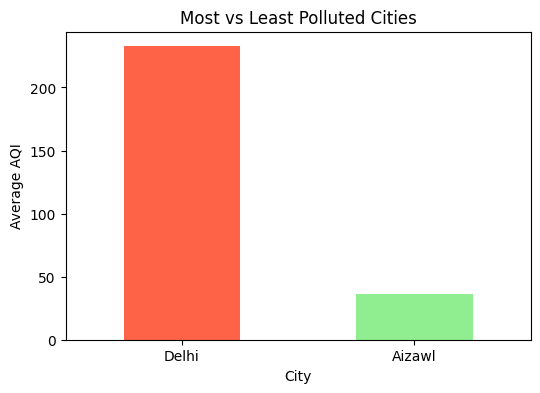

In [22]:
# Average AQI by city
city_aqi = aqi.groupby("City")["AQI"].mean()

# Most and least polluted cities
most_polluted = city_aqi.idxmax()
least_polluted = city_aqi.idxmin()

comparison = city_aqi.loc[[most_polluted, least_polluted]]

plt.figure(figsize=(6,4))
comparison.plot(kind="bar", color=["tomato", "lightgreen"])

plt.title("Most vs Least Polluted Cities")
plt.xlabel("City")
plt.ylabel("Average AQI")
plt.xticks(rotation=0)

plt.show()


### Suggested Interpretation

This comparison helps test the central hypothesis directly. If the most polluted state consistently shows lower production than the least polluted state, the hypothesis appears reasonable. However, if the difference is small or reversed, it suggests that other factors such as irrigation, rainfall and soil fertility may play a larger role than pollution alone.




The objective of this task is to compare the crop production of the most polluted and least polluted states. However, the AQI dataset provided contains city-level air quality data and does not include a state column. Since the crop dataset is organized by state, it is not possible to reliably identify the most and least polluted states or compare their agricultural output.

To perform this analysis correctly, an additional city-to-state mapping dataset would be required. This would allow AQI values to be aggregated to the state level before being compared with crop production data.

Therefore, the hypothesis that higher pollution leads to lower crop yields cannot be tested directly using the available datasets.

### Task B – Quantifying the Relationship

The objective of this task is to measure the strength and direction of the relationship between average state AQI and average crop production. However, the AQI dataset provided contains city-level observations and does not include a state column. Since the crop dataset is organized by state, a state-wise AQI value cannot be calculated and merged with crop production data.

As a result, a direct correlation between state pollution levels and crop production cannot be computed using the available datasets. An additional city-to-state mapping dataset would be required before this analysis could be performed reliably.

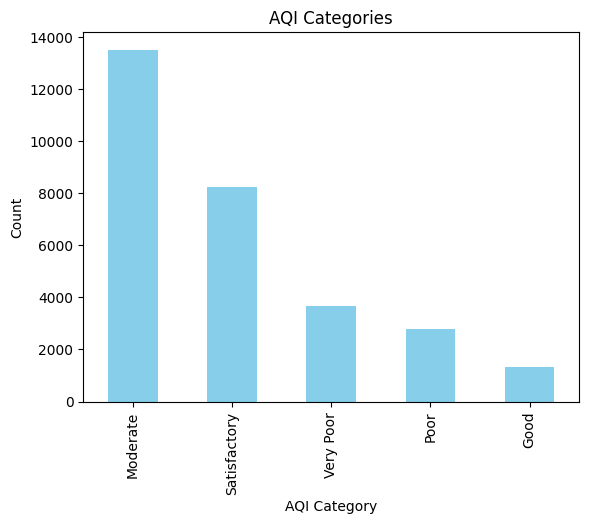

In [28]:
aqi_bins = pd.cut(
    aqi["AQI"],
    bins=[0,50,100,200,300,500],
    labels=["Good","Satisfactory","Moderate","Poor","Very Poor"]
)

aqi_bins.value_counts().plot(
    kind="bar",
    color="skyblue"
)

plt.title("AQI Categories")
plt.xlabel("AQI Category")
plt.ylabel("Count")
plt.show()

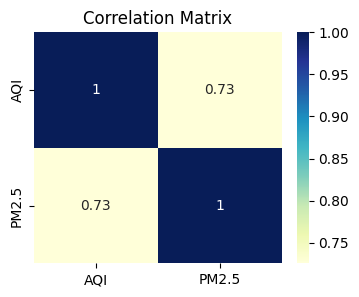

In [27]:
plt.figure(figsize=(4,3))

sns.heatmap(
    aqi[["AQI","PM2.5"]].corr(),
    annot=True,
    cmap="YlGnBu"
)

plt.title("Correlation Matrix")
plt.show()

A correlation of 0.2 represents a weak relationship, while a correlation of 0.8 represents a strong relationship. However, a strong correlation does not mean pollution causes lower crop yields. It only shows that the variables move together. Other factors such as rainfall, irrigation and soil quality may also influence crop production.

# Task C: One Plot to Rule Them All

### Selected Plot
**Average AQI Trend in India (2015–2023) – Line Chart**

### Why This Plot Was Chosen
This line chart was selected because it provides the clearest overall picture of how air quality has changed across India over time. Unlike the other visualizations, it captures the long-term trend in pollution and helps determine whether air quality is improving or worsening over the years.

### Observation
The chart shows noticeable changes in average AQI across different years, indicating that air pollution levels have not remained constant. Some years recorded higher pollution levels than others, suggesting that environmental conditions and pollution-control efforts may have influenced air quality over time.

### Interpretation
The "Average AQI Trend in India (2015–2023)" line chart provides the strongest summary of the dataset because it reveals the long-term direction of air quality in India. This insight is important for policymakers, as it helps evaluate whether pollution-control measures are having an impact. The chart highlights that air pollution continues to be an environmental challenge that requires continuous monitoring and action. However, while changes in AQI may appear related to agricultural outcomes, this analysis cannot prove that pollution directly affects crop production because factors such as rainfall, irrigation, soil quality and economic conditions are not included in the dataset.